# Daily station weather

The Global Historical Climatology Network daily dataset (GHCN-Daily) is
NOAA's archive of daily observations from land stations: maximum and minimum
temperature, precipitation, snowfall, snow depth, and other elements from
more than 100,000 stations in 180 countries and territories, some going back
to the eighteenth century. NCEI assembles it from many source networks,
quality-controls it, and serves it through its Access Data Service; one
request returns one CSV with a row per station and day.

This walkthrough pulls every day of 2024 at Will Rogers World Airport in
Oklahoma City: high and low temperature, precipitation, and snowfall. It
needs `usdata[pandas]` and matplotlib, downloads about 30 kB, and runs in a
few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-25T15:36:05+00:00
usdata 0.27.0; pandas 3.0.6


## Select

The manifest names one station, four element codes, and a window. Dates are
inclusive calendar dates and any time of day is ignored. `USW00013967` is the
airport's GHCN station ID; a `bbox` or `place` in place of `stations` finds
stations through NCEI's search service, which is how to reach the volunteer
and cooperative stations near a city. `TMAX` and `TMIN` are
the day's high and low, `PRCP` its precipitation, and `SNOW` its snowfall.
`units: metric` asks for degrees Celsius and millimetres.

In [2]:
print(manifest.read_text())

name: okc-daily-weather
sources:
  - dataset: noaa:ghcn-daily
    start: 2024-01-01
    end: 2024-12-31
    variables: [TMAX, TMIN, PRCP, SNOW]
    params:
      stations: USW00013967
      units: metric



## What arrives

The first pull downloads one CSV and writes `dataset.lock.json` beside the
manifest, pinning the file's checksum. NCEI rebuilds GHCN-Daily every weekend
and replaces real-time values with archive sources 45 to 60 days after a
month ends, so a later pull of the same days can return different bytes; the
lockfile records which ones this analysis used.

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)

File: daily-summaries_2024-01-01_2024-12-31_eab4db696c51.csv
Bytes: 30726
Source: https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&stations=USW00013967&startDate=2024-01-01&endDate=2024-12-31&format=csv&units=metric&includeStationLocation=1&dataTypes=TMAX%2CTMIN%2CPRCP%2CSNOW
Retrieved (UTC): 2026-09-25T15:36:06+00:00
Checksum: sha256:0ba8cb9e10a9457eee1d942a3bf0e5445c41ed73137673292dfadf68ac19028a


## Open

The generic CSV reader returns a DataFrame with one row per station and day.
`DATE` is a calendar date with no time or time zone: the station's
observation day. Elements are columns named by their codes, in alphabetical
order. NCEI's CSV has no units row, so the units come from the request:
`TMAX` and `TMIN` in degrees Celsius, `PRCP` and `SNOW` in millimetres. Each
row repeats the station's latitude, longitude, and elevation in metres.

In [4]:
frame = item.open_csv(parse_dates=["DATE"])
elements = ["TMAX", "TMIN", "PRCP", "SNOW"]
print(f"{len(frame)} rows, {frame['DATE'].min():%Y-%m-%d} to {frame['DATE'].max():%Y-%m-%d}")
print("Missing values per element:", frame[elements].isna().sum().to_dict())
frame[["STATION", "DATE", *elements]].head()

366 rows, 2024-01-01 to 2024-12-31
Missing values per element: {'TMAX': 0, 'TMIN': 0, 'PRCP': 0, 'SNOW': 0}


,STATION,DATE,TMAX,TMIN,PRCP,SNOW
0,USW00013967,2024-01-01,5.0,-2.7,0.0,0.0
1,USW00013967,2024-01-02,8.9,-4.3,0.0,0.0
2,USW00013967,2024-01-03,10.6,-2.1,0.0,0.0
3,USW00013967,2024-01-04,11.7,-1.0,2.5,0.0
4,USW00013967,2024-01-05,5.0,1.7,5.3,0.0


## A first look

A year of daily highs and lows as a band, with daily precipitation below it.

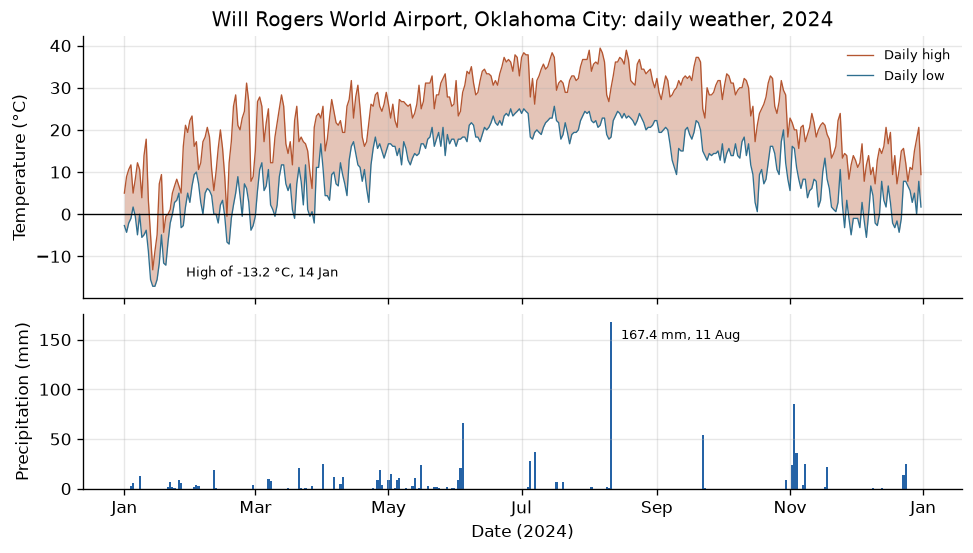

In [5]:
coldest = frame.loc[frame["TMAX"].idxmin()]
wettest = frame.loc[frame["PRCP"].idxmax()]

fig, (warm, wet) = plt.subplots(
    2, 1, sharex=True, layout="constrained", gridspec_kw={"height_ratios": [3, 2]}
)
warm.fill_between(
    frame["DATE"], frame["TMIN"], frame["TMAX"], color="#b45631", alpha=0.35, linewidth=0
)
warm.plot(frame["DATE"], frame["TMAX"], color="#b45631", linewidth=0.8, label="Daily high")
warm.plot(frame["DATE"], frame["TMIN"], color="#2f6f8f", linewidth=0.8, label="Daily low")
warm.axhline(0, color="black", linewidth=0.8)
warm.annotate(
    f"High of {coldest['TMAX']:.1f} °C, {coldest['DATE']:%d %b}",
    (coldest["DATE"], coldest["TMAX"]),
    xytext=(20, -4),
    textcoords="offset points",
    fontsize=8,
)
warm.set_ylabel("Temperature (°C)")
warm.set_title("Will Rogers World Airport, Oklahoma City: daily weather, 2024")
warm.legend(loc="upper right", fontsize=8, frameon=False)
wet.bar(frame["DATE"], frame["PRCP"], width=1, color="#2563a6")
wet.annotate(
    f"{wettest['PRCP']:.1f} mm, {wettest['DATE']:%d %b}",
    (wettest["DATE"], wettest["PRCP"]),
    xytext=(6, -10),
    textcoords="offset points",
    fontsize=8,
)
wet.set_ylabel("Precipitation (mm)")
wet.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
wet.set_xlabel("Date (2024)")
plt.show()

In [6]:
total = frame["PRCP"].sum()
wet_days = int((frame["PRCP"] > 0).sum())
top_days = frame.nlargest(3, "PRCP")
print(f"Precipitation in 2024: {total:.0f} mm on {wet_days} days")
top_total = top_days["PRCP"].sum()
print(f"Three wettest days: {top_total:.0f} mm, {top_total / total:.0%} of the year")
print(f"Wettest day {wettest['DATE']:%Y-%m-%d}: {wettest['PRCP']:.1f} mm")
print(f"Days with a high of 35 °C or more: {int((frame['TMAX'] >= 35).sum())}")
print(f"Days with a low below 0 °C: {int((frame['TMIN'] < 0).sum())}")
snow_days = frame.loc[frame["SNOW"] > 0, "DATE"].dt.strftime("%d %b")
print(f"Snowfall: {frame['SNOW'].sum():.0f} mm, on {', '.join(snow_days)}")

Precipitation in 2024: 942 mm on 73 days
Three wettest days: 318 mm, 34% of the year
Wettest day 2024-08-11: 167.4 mm
Days with a high of 35 °C or more: 41
Days with a low below 0 °C: 51
Snowfall: 87 mm, on 14 Jan, 11 Feb, 12 Feb, 27 Mar


Oklahoma City's 2024 precipitation came in bursts: most days were dry, and
three days supplied about a third of the year's total, led by 167.4 mm on 11
August. The coldest stretch was the mid-January Arctic outbreak, when the
high on 14 January stayed at -13.2 °C. A daily record is what shows these
single-day events; the [monthly summaries](https://usdata.dev/datasets/noaa/gsom/)
built from it fold them into totals and means.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Because NCEI
revises GHCN-Daily, keep the cache with the manifest and lockfile; a checksum
cannot recreate bytes upstream has replaced. `usdata cite dataset.yaml`
prints the same citation.

In [7]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:ghcn-daily
  Menne, M.J., I. Durre, R.S. Vose, B.E. Gleason, and T.G. Houston, 2012: An overview of the Global Historical Climatology Network-Daily Database. Journal of Atmospheric and Oceanic Technology, 29, 897-910, doi:10.1175/JTECH-D-11-00103.1
  homepage: https://www.ncei.noaa.gov/products/land-based-station/global-historical-climatology-network-daily
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc:C00861/html
  retrieved: 2026-09-25; 1 checksummed asset (30,726 bytes) pinned by usdata 0.27.0
  sources: 1


## What was awkward

- The CSV carries no units. `SNOW` under `units: metric` is millimetres of
  snowfall, not centimetres. The manifest's `units` used to be the only record
  of either; the frame now keeps it in `attrs["usdata"]["properties"]`.
- `DATE` has no time zone or observing time. An airport's day runs midnight
  to midnight local standard time, but many cooperative stations report a
  24-hour period ending in the morning, so the same `DATE` at two stations
  can cover different hours.
- Values change after the fact: real-time values are replaced 45 to 60 days
  after the month ends, so a recent window pulled twice can disagree with its
  own lockfile.
- Station discovery runs through a separate search service that can fail
  while data requests still work. Explicit `stations` avoid it, at the cost of
  finding the ID elsewhere first.